In [1]:
! which python 

/home/zhanyu/anaconda3/envs/kaggle/bin/python


# 海航同一航线航段分配

多项式回归：用于处理输入特征和目标之间的非线性关系。通过将输入特征进行多项式扩展，将问题转换为线性回归。

支持向量回归（SVR）：基于支持向量机（SVM）的回归方法，适用于处理高维数据和复杂的非线性关系。

决策树回归：基于决策树的回归方法，可以处理非线性关系和复杂的数据模式。

随机森林回归：通过集成多个决策树模型来提高预测性能，适用于处理大规模数据集。

## 实现几个函数来方便下载数据

In [2]:
import hashlib  # 导入哈希库，用于生成文件的SHA-1哈希值
import os       # 导入os库，用于文件路径和目录操作
import tarfile  # 导入tarfile库，用于解压tar格式文件
import zipfile  # 导入zipfile库，用于解压zip格式文件
import requests # 导入requests库，用于发送HTTP请求下载文件

## 访问和读取数据集

使用9sFh30Q0Yws=航班2023全年的数据作为训练集，2024的数据作为测试集

有的是直飞数据，有的是甩飞数据，我们只关心甩飞数据

不同行之间的区别在于，有的

In [3]:
%matplotlib inline 

import numpy as np  # 导入NumPy库，用于数组和矩阵计算
import pandas as pd  # 导入Pandas库，用于数据处理和分析
import glob # 用于匹配当前目录下的文件名模式
import torch  # 导入PyTorch库，用于构建和训练深度学习模型
from torch import nn  # 从torch中导入神经网络模块
from d2l import torch as d2l  # 从d2l库中导入PyTorch部分，提供深度学习工具


# 航班基础数据加载为Pandas数据框
train_data_origin = pd.read_csv('/home/zhanyu/experiment/data-hh/航班销售结果数据/mid_flt_segment_sum_tmp_202410241005.csv')


# 航班销售结果数据加载为Pandas数据框
test_data_origin = pd.read_csv('/home/zhanyu/experiment/data-hh/航班销售结果数据/mid_flt_segment_sum_tmp_202410241006.csv')

In [4]:
# 将 flt_no 值保存在变量中
flt_no_value = '86i3lia5Jj4='

# 假设 train_data 是已加载的数据框
# 筛选出 flt_no 为 flt_no_value 的行
train_data = train_data_origin[train_data_origin['flt_no'] == flt_no_value]
test_data = test_data_origin[test_data_origin['flt_no'] == flt_no_value]


# 定义保存路径
train_save_path = f'/home/zhanyu/experiment/data-hh/my/train_{flt_no_value}.csv'
test_save_path = f'/home/zhanyu/experiment/data-hh/my/test_{flt_no_value}.csv'

# 创建目录（如果目录不存在）
if not os.path.exists('/home/zhanyu/experiment/data-hh/my'):
    os.makedirs('/home/zhanyu/experiment/data-hh/my')


print(train_data.shape)
print(test_data.shape)

(964, 13)
(468, 13)


train和test中有一些数据项c=NaN,把这些数据删除

In [5]:
print(train_data['c'].isna().sum())
print(test_data['c'].isna().sum())

76
21


In [6]:
# 删除 'c' 列为 NaN 的行
train_data = train_data.dropna(subset=['c'])
test_data = test_data.dropna(subset=['c'])


print(train_data['c'].isna().sum())
print(test_data['c'].isna().sum())

0
0


同一个航班有两条航线，选择多的那条来计算

In [7]:
# 统计 'a' 列的取值及其出现次数
value_counts = train_data['a'].value_counts()

# 打印统计结果
print(value_counts)

# 使用布尔索引筛选 'a' 列为 'zwVGiYamVc0=' 的行
train_data = train_data[train_data['a'] == 'zwVGiYamVc0=']
test_data = test_data[test_data['a'] == 'zwVGiYamVc0=']

# 统计 'a' 列的取值及其出现次数
value_counts = train_data['a'].value_counts()

# 打印统计结果
print(value_counts)

a
zwVGiYamVc0=    444
Qe7TEMbQt6o=    444
Name: count, dtype: int64
a
zwVGiYamVc0=    444
Name: count, dtype: int64


In [8]:
# 统计 'flt_date' 列的取值及其出现次数
value_counts = train_data['flt_date'].value_counts()

# 打印统计结果
print(value_counts)

# 判断是否有统计值 > 3 的情况
if (value_counts > 3).any():
    print("存在统计值大于 3 的情况：")
    print(value_counts[value_counts > 3])
else:
    print("没有统计值大于 3 的情况。")


flt_date
2023-01-01    3
2023-11-07    3
2023-11-09    3
2023-11-10    3
2023-11-11    3
             ..
2023-02-19    3
2023-02-20    3
2023-02-21    3
2023-02-22    3
2023-12-31    3
Name: count, Length: 148, dtype: int64
没有统计值大于 3 的情况。


In [9]:
# 保存筛选后的数据到指定路径
train_data.to_csv(train_save_path, index=False)
test_data.to_csv(test_save_path, index=False)

# 提示保存成功
print(f"数据已保存为 '{train_save_path}'")
print(f"数据已保存为 '{test_save_path}'")

数据已保存为 '/home/zhanyu/experiment/data-hh/my/train_86i3lia5Jj4=.csv'
数据已保存为 '/home/zhanyu/experiment/data-hh/my/test_86i3lia5Jj4=.csv'


In [10]:
# 第一行的数据以及数据段
    # mid_flt_segment_sum_tmp_202410241005.csv加载的是2023年全年的销售结果,812968条数据
    # mid_flt_segment_sum_tmp_202410241006.csv加载的是2024年1-1到6-30的销售结果,413777条数据
print('train')
print(train_data.shape)
print(train_data.iloc[0, :])

print("")
print('test_data')
print(test_data.shape)
print(test_data.iloc[0, :])

train
(444, 13)
flt_date                   2023-01-01
a                        zwVGiYamVc0=
b                        FWD6O2fHsIU=
c                        wSF4qXvI044=
segment     FWD6O2fHsIU=-wSF4qXvI044=
flt_no                   86i3lia5Jj4=
aircraft                          738
duration                         1.87
y_rev                         50795.0
y_pax                             106
y_cap                             155
c_rev                           155.0
c_pax                               7
Name: 11, dtype: object

test_data
(270, 13)
flt_date                   2024-01-01
a                        zwVGiYamVc0=
b                        FWD6O2fHsIU=
c                        wSF4qXvI044=
segment     zwVGiYamVc0=-wSF4qXvI044=
flt_no                   86i3lia5Jj4=
aircraft                          738
duration                          4.3
y_rev                         31260.0
y_pax                              37
y_cap                               0
c_rev                      

In [11]:
# 创建 train_data 和 test_data 的副本，避免修改原数据框
train_data_copy = train_data.copy()
test_data_copy = test_data.copy()

# 删除 train_data_copy 的后五列
train_data_copy = train_data_copy.iloc[:, :-5]

# 删除 test_data_copy 的倒数第5, 3, 2 列
test_data_copy = test_data_copy.drop(test_data_copy.columns[-5], axis=1)
test_data_copy = test_data_copy.drop(test_data_copy.columns[-3], axis=1)
test_data_copy = test_data_copy.drop(test_data_copy.columns[-2], axis=1)
test_data_copy = test_data_copy.drop(test_data_copy.columns[-1], axis=1)

# 列对齐：拼接时，列名对齐，不存在的列会填充为 NaN
all_features = pd.concat((train_data_copy, test_data_copy), axis=0)

In [12]:
# 将 'flt_date' 列从字符串类型转换为 datetime 类型
all_features['flt_date'] = pd.to_datetime(all_features['flt_date'])

# 提取年、月、日、星期几等信息
all_features['year'] = all_features['flt_date'].dt.year
all_features['month'] = all_features['flt_date'].dt.month
all_features['day'] = all_features['flt_date'].dt.day
all_features['weekday'] = all_features['flt_date'].dt.weekday  # 星期几（0 = 周一, 6 = 周日）

all_features.drop('flt_date', axis=1, inplace=True)

In [13]:
print(all_features.shape)
print(all_features.iloc[0, :])
print()
print(all_features.iloc[-1, :])

(714, 12)
a                        zwVGiYamVc0=
b                        FWD6O2fHsIU=
c                        wSF4qXvI044=
segment     FWD6O2fHsIU=-wSF4qXvI044=
flt_no                   86i3lia5Jj4=
aircraft                          738
duration                         1.87
y_pax                             NaN
year                             2023
month                               1
day                                 1
weekday                             6
Name: 11, dtype: object

a                        zwVGiYamVc0=
b                        FWD6O2fHsIU=
c                        wSF4qXvI044=
segment     FWD6O2fHsIU=-wSF4qXvI044=
flt_no                   86i3lia5Jj4=
aircraft                          738
duration                         1.97
y_pax                            99.0
year                             2024
month                               3
day                                30
weekday                             5
Name: 205921, dtype: object


## 数据预处理

In [14]:
# 将所有缺失的值替换为相应特征的平均值。 通过将特征重新缩放到零均值和单位方差来标准化数据
# 选择所有数值类型的特征（即不包括类别型特征）
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index

# 对所有数值型特征进行标准化，即将每个特征的均值变为0，标准差变为1
# 使用apply函数对每个数值型特征列进行操作，lambda表达式表示每列数据减去均值并除以标准差
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))
    
# 对所有数值型特征进行缺失值填充，填充的值是该特征列的均值（0）
all_features[numeric_features] = all_features[numeric_features].fillna(0)

In [15]:
print(all_features.shape)
print(all_features.iloc[0, :])
print()
print(all_features.iloc[-1, :])

(714, 12)
a                        zwVGiYamVc0=
b                        FWD6O2fHsIU=
c                        wSF4qXvI044=
segment     FWD6O2fHsIU=-wSF4qXvI044=
flt_no                   86i3lia5Jj4=
aircraft                          738
duration                    -0.968068
y_pax                             0.0
year                        -0.779267
month                        -0.82087
day                         -1.661754
weekday                      1.498949
Name: 11, dtype: object

a                        zwVGiYamVc0=
b                        FWD6O2fHsIU=
c                        wSF4qXvI044=
segment     FWD6O2fHsIU=-wSF4qXvI044=
flt_no                   86i3lia5Jj4=
aircraft                          738
duration                    -0.874244
y_pax                        0.390465
year                         1.281461
month                       -0.352925
day                          1.676262
weekday                      0.999299
Name: 205921, dtype: object


In [16]:
print(all_features.shape)
print(all_features.iloc[0, :])
print()
print(all_features.iloc[-1, :])

(714, 12)
a                        zwVGiYamVc0=
b                        FWD6O2fHsIU=
c                        wSF4qXvI044=
segment     FWD6O2fHsIU=-wSF4qXvI044=
flt_no                   86i3lia5Jj4=
aircraft                          738
duration                    -0.968068
y_pax                             0.0
year                        -0.779267
month                        -0.82087
day                         -1.661754
weekday                      1.498949
Name: 11, dtype: object

a                        zwVGiYamVc0=
b                        FWD6O2fHsIU=
c                        wSF4qXvI044=
segment     FWD6O2fHsIU=-wSF4qXvI044=
flt_no                   86i3lia5Jj4=
aircraft                          738
duration                    -0.874244
y_pax                        0.390465
year                         1.281461
month                       -0.352925
day                          1.676262
weekday                      0.999299
Name: 205921, dtype: object


In [17]:
# 处理离散值。我们用一次独热编码替换它们
# pd.get_dummies() 用于将所有类别型（离散型）特征进行独热编码。
# 参数 dummy_na=True 表示将缺失值（NaN）也转换为一个新的列，表示是否为缺失值。
all_features = pd.get_dummies(all_features, dummy_na=True)

# 输出转换后的数据框的形状（行数和列数），查看独热编码后的结果
all_features.shape

(714, 25)

In [18]:
print(all_features.iloc[0, :])

duration                            -0.968068
y_pax                                     0.0
year                                -0.779267
month                                -0.82087
day                                 -1.661754
weekday                              1.498949
a_zwVGiYamVc0=                           True
a_nan                                   False
b_FWD6O2fHsIU=                           True
b_nan                                   False
c_wSF4qXvI044=                           True
c_nan                                   False
segment_FWD6O2fHsIU=-wSF4qXvI044=        True
segment_zwVGiYamVc0=-FWD6O2fHsIU=       False
segment_zwVGiYamVc0=-wSF4qXvI044=       False
segment_nan                             False
flt_no_86i3lia5Jj4=                      True
flt_no_nan                              False
aircraft_331                            False
aircraft_333                            False
aircraft_338                            False
aircraft_738                      

In [19]:
# 获取训练集的样本数量（行数）
n_train = train_data.shape[0]

# 提取训练集特征并转换为PyTorch张量
# all_features[:n_train].values 选取所有特征的前 n_train 行作为训练集的特征
# .astype(float) 将数据转换为浮点型，以确保数据格式一致
# torch.tensor(..., dtype=torch.float32) 将数据转换为32位浮点数格式的PyTorch张量
train_features = torch.tensor(all_features[:n_train].values.astype(float), dtype=torch.float32)

# 提取测试集特征并转换为PyTorch张量
# all_features[n_train:].values 选取所有特征的从第 n_train 行开始的所有行，作为测试集的特征
# .astype(float) 将数据转换为浮点型
# torch.tensor(..., dtype=torch.float32) 将数据转换为32位浮点数格式的PyTorch张量
test_features = torch.tensor(all_features[n_train:].values.astype(float), dtype=torch.float32)

# 提取训练集标签（房价）并转换为PyTorch张量
# train_data.SalePrice.values 获取训练集标签列（房价）的数值
# .astype(float).reshape(-1, 1) 将数据转换为浮点型并重塑为列向量（每行一个房价标签）
# torch.tensor(..., dtype=torch.float32) 将标签转换为32位浮点数格式的PyTorch张量
train_labels = torch.tensor(
    train_data.y_pax.values.astype(float).reshape(-1, 1), dtype=torch.float32)

## 训练

In [21]:
# 定义均方误差（MSE）损失函数，用于回归问题，计算预测值与真实值的平方差平均值
loss = nn.MSELoss()

# 获取输入特征的维度（列数），用于设置神经网络线性层的输入大小
in_features = train_features.shape[1]

# 定义一个简单的神经网络模型，包含一个输入层和一个输出层
def get_net():
    # nn.Sequential 创建顺序容器模型，这里包含一个线性层
    # nn.Linear(in_features, 1) 表示从输入特征数映射到1个输出值
    net = nn.Sequential(nn.Linear(in_features, 1))
    return net

# 定义计算对数均方根误差（log RMSE）的函数
# 我们更关心预测误差的相对大小，而不是绝对误差，因此使用对数来衡量差异
def log_rmse(net, features, labels):
    # 使用 torch.clamp 将预测值限制为不小于1，以避免对数计算中的负数和无穷大问题
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    # 计算对数均方根误差：先取对数再计算均方误差，最后开方
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    # 返回误差值（标量），用于模型评估
    return rmse.item()

# 定义模型训练函数，使用Adam优化算法进行优化
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    # 初始化用于存储训练误差和测试误差的列表
    train_ls, test_ls = [], []
    
    # 将训练特征和标签数据按批量大小加载到数据迭代器中，以便进行小批量训练
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    
    # 使用 Adam 优化器来更新网络参数，设置学习率和权重衰减
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr=learning_rate,
                                 weight_decay=weight_decay)
    
    # 训练过程，循环执行每个 epoch
    for epoch in range(num_epochs):
        # 遍历每个小批量数据
        for X, y in train_iter:
            optimizer.zero_grad()  # 清除梯度
            l = loss(net(X), y)    # 计算当前批量的损失
            l.backward()           # 反向传播计算梯度
            optimizer.step()       # 优化器更新模型参数
        
        # 每个 epoch 结束后，计算训练集上的对数均方根误差并记录
        train_ls.append(log_rmse(net, train_features, train_labels))
        
        # 如果有测试集，计算测试集上的对数均方根误差并记录
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    
    # 返回训练误差和测试误差（按 epoch 记录）
    return train_ls, test_ls


## k折交叉验证

In [22]:
# 获取第i折的训练集和验证集数据
def get_k_fold_data(k, i, X, y):
    # 确保 k > 1，因为至少需要两个折
    assert k > 1
    # 计算每折数据的大小
    fold_size = X.shape[0] // k
    # 初始化训练集特征和标签为空
    X_train, y_train = None, None
    for j in range(k):
        # 使用切片选择第 j 折的数据
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:  # 第 i 折作为验证集
            X_valid, y_valid = X_part, y_part
        elif X_train is None:  # 初始化训练集为第一个非验证折
            X_train, y_train = X_part, y_part
        else:  # 将其他折的数据追加到训练集
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    # 返回训练集和验证集的数据
    return X_train, y_train, X_valid, y_valid

# 执行 K 折交叉验证并计算训练和验证误差的平均值
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,
           batch_size):
    # 初始化训练和验证误差的累积值
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        # 获取第 i 折的训练和验证数据
        data = get_k_fold_data(k, i, X_train, y_train)
        # 获取新的网络模型
        net = get_net()
        # 使用第 i 折的数据训练模型并获取误差
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)
        # 累加最后一个 epoch 的训练和验证误差
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        
        # 在第一个折上绘制训练和验证误差的曲线图
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        
        # 输出当前折的训练和验证误差
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    
    # 返回训练和验证误差的平均值
    return train_l_sum / k, valid_l_sum / k


## 模型选择

折1，训练log rmse0.322604, 验证log rmse0.314491
折2，训练log rmse0.316977, 验证log rmse0.346475
折3，训练log rmse0.329132, 验证log rmse0.367991
折4，训练log rmse0.358395, 验证log rmse0.295636
折5，训练log rmse0.336283, 验证log rmse0.218428
折6，训练log rmse0.363338, 验证log rmse0.292669
折7，训练log rmse0.313777, 验证log rmse0.443390
折8，训练log rmse0.322296, 验证log rmse0.301995
折9，训练log rmse0.314561, 验证log rmse0.412921
折10，训练log rmse0.338781, 验证log rmse0.475041
10-折验证: 平均训练log rmse: 0.331614, 平均验证log rmse: 0.346904


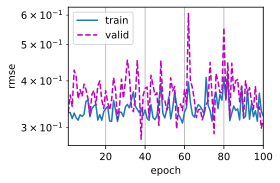

In [23]:
# 设置 K 折交叉验证的超参数
#k = 5：设置交叉验证的折数为5，即将数据分为5份，每次使用其中一份作为验证集，其余四份作为训练集。
#num_epochs = 100：设置模型训练的总轮数为100。
#lr = 5：设置学习率为5，控制模型参数的更新步长。
#weight_decay = 0：设置权重衰减系数（正则化参数）为0，即不使用正则化。
#batch_size = 64：设置小批量梯度下降的批量大小为64。
k, num_epochs, lr, weight_decay, batch_size = 10, 100, 2, 0, 8

# 使用 K 折交叉验证来评估模型性能，返回训练误差和验证误差的平均值
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)

# 打印 K 折验证结果，输出训练集和验证集上的平均对数均方根误差
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')